# 4. Actividad Opcional sobre RAPIDS: Aplicación de filtros adicionales para un análisis más profundo del dataset `nyc-parking-tickets`
---

In [1]:
# Instalar bibliotecas necesarias
!uv pip install dask distributed --quiet  # Para trabajar con Dask
!uv pip install cudf-cu12 dask-cudf-cu12 --extra-index-url=https://pypi.nvidia.com
!uv pip install pyngrok --quiet  # Para exponer el dashboard de Dask
!uv pip install kagglehub # Para extraer el dataset directamente desde Kaggle

Resolved 57 packages in 4.96s                                        
Uninstalled 3 packages in 16ms
Installed 3 packages in 12ms                                
 - dask==2026.3.0
 + dask==2026.1.1
 - distributed==2026.3.0
 + distributed==2026.1.1
 - pandas==3.0.2
 + pandas==2.3.3
Checked 1 package in 2ms


In [2]:
# Importar librerías
from dask.distributed import Client, LocalCluster
from pyngrok import ngrok
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

# 4.0. Exponer el Dashboard de Dask con ngrok y configuración del clúster en modo GPU

In [3]:
# Función para exponer el dashboard de Dask con ngrok
def expose_dashboard(cluster):
    ngrok.set_auth_token("3DGUSrNgMvLKPTUmNUW5yTWO6gG_K8JaZSLeymSDNRoijoV1")
    public_url = ngrok.connect(8787)  # Puerto por defecto del dashboard de Dask
    print(f"El dashboard de Dask está disponible en: {public_url}")
    return public_url


def setup_cluster():
    cluster = LocalCluster(
        n_workers=2,  # número de workers
        threads_per_worker=2,  # hilos por worker
        memory_limit="7GB",  # límite de RAM por worker
        dashboard_address=":8787",  # dashboard en el puerto 8787
    )

    # Conectar al cluster
    client = Client(cluster)
    print(client)  # Mostrar información del cliente
    expose_dashboard(cluster)  # Exponer el dashboard
    return client


client_cpu = setup_cluster()

<Client: 'tcp://127.0.0.1:43261' processes=2 threads=4, memory=13.04 GiB>
El dashboard de Dask está disponible en: NgrokTunnel: "https://4702-88-98-121-210.ngrok-free.app" -> "http://localhost:8787"


2026-05-07 00:23:19,642 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 4c1b8dd7adb3a234935095691105fb2f initialized by task ('shuffle-transfer-4c1b8dd7adb3a234935095691105fb2f', 308) executed on worker tcp://127.0.0.1:35801
2026-05-07 00:23:34,760 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 4c1b8dd7adb3a234935095691105fb2f deactivated due to stimulus 'task-finished-1778106214.7568429'
2026-05-07 00:23:35,532 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 67e3bb1d6dfbffb6d98248503efcd23b initialized by task ('shuffle-transfer-67e3bb1d6dfbffb6d98248503efcd23b', 290) executed on worker tcp://127.0.0.1:38495
2026-05-07 00:23:54,722 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 67e3bb1d6dfbffb6d98248503efcd23b deactivated due to stimulus 'task-finished-1778106234.7213182'
2026-05-07 00:23:55,358 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle b59d7838bc3b383ebb5a8237af211328 initialized by task ('shuffle-transfer-b59d7838bc

# 4.1. Cargar y limpiar datos

In [4]:
import dask_cudf as dd
import os
import kagglehub

# Descargamos el dataset

dataset_name = "new-york-city/nyc-parking-tickets"
path = kagglehub.dataset_download(dataset_name)
os.makedirs(path, exist_ok=True)

# Cargamos cada archivo en un DataFrame de Dask distinto
tickets14 = dd.read_csv(
    os.path.join(
        path,
        "Parking_Violations_Issued_-_Fiscal_Year_2014__August_2013___June_2014_.csv",
    ),
    assume_missing=True,
    sample=10000,
)
print("Columnas y Tipos de datos 2014: \n", tickets14.dtypes)
print("Número de Columnas", len(set(tickets14.columns)))
print("--" * 30)
print()

tickets15 = dd.read_csv(
    os.path.join(path, "Parking_Violations_Issued_-_Fiscal_Year_2015.csv"),
    assume_missing=True,
    sample=10000,
)
print("Columnas y Tipos de datos 2015: \n", tickets15.dtypes)
print("Número de Columnas", len(set(tickets15.columns)))
print("--" * 30)
print()

tickets16 = dd.read_csv(
    os.path.join(path, "Parking_Violations_Issued_-_Fiscal_Year_2016.csv"),
    assume_missing=True,
    sample=10000,
)
print("Columnas y Tipos de datos 2016:\n", tickets16.dtypes)
print("Número de Columnas", len(set(tickets16.columns)))
print("--" * 30)
print()

tickets17 = dd.read_csv(
    os.path.join(path, "Parking_Violations_Issued_-_Fiscal_Year_2017.csv"),
    assume_missing=True,
    sample=10000,
)
print("Columnas y Tipos de datos 2017:\n", tickets17.dtypes)
print("Número de Columnas", len(set(tickets17.columns)))

tickets = {
    "tickets14": tickets14,
    "tickets15": tickets15,
    "tickets16": tickets16,
    "tickets17": tickets17,
}

# Comparar columnas entre todos los pares de DataFrames
for name1, df1 in tickets.items():
    for name2, df2 in tickets.items():
        if name1 >= name2:
            continue
        if set(df1.columns) != set(df2.columns):
            print(f"Diferencia de columnas entre {name1} y {name2}")

[234958][00:22:55:698684][warning] Auto detection of compression type is supported only for file type buffers. For other buffer types, AUTO compression type assumes uncompressed input.
[234958][00:22:55:860026][warning] Auto detection of compression type is supported only for file type buffers. For other buffer types, AUTO compression type assumes uncompressed input.
[234958][00:22:55:883275][warning] Auto detection of compression type is supported only for file type buffers. For other buffer types, AUTO compression type assumes uncompressed input.


Columnas y Tipos de datos 2014: 
 Summons Number                               float64
Plate ID                             string[pyarrow]
Registration State                   string[pyarrow]
Plate Type                           string[pyarrow]
Issue Date                           string[pyarrow]
Violation Code                               float64
Vehicle Body Type                    string[pyarrow]
Vehicle Make                         string[pyarrow]
Issuing Agency                       string[pyarrow]
Street Code1                                 float64
Street Code2                                 float64
Street Code3                                 float64
Vehicle Expiration Date                      float64
Violation Location                           float64
Violation Precinct                           float64
Issuer Precinct                              float64
Issuer Code                                  float64
Issuer Command                               float64
Issuer Squad

[234958][00:22:55:904544][warning] Auto detection of compression type is supported only for file type buffers. For other buffer types, AUTO compression type assumes uncompressed input.


### Extraemos columnas comunes entre los 4 archivos

In [5]:
# Obtenemos las columnas comunes entre los DataFrames
common_cols = list(
    set(tickets14.columns).intersection(
        tickets15.columns, tickets16.columns, tickets17.columns
    )
)

### Especifica el esquema de tipo de datos deseado para el DataFrame de Dask: convierte todas las columnas comunes a `'str'`

In [6]:
# Convertimos todas las columnas comunes a string y cargamos solamente estas
data_types = {col: "str" for col in common_cols}

tickets14 = dd.read_csv(
    os.path.join(
        path,
        "Parking_Violations_Issued_-_Fiscal_Year_2014__August_2013___June_2014_.csv",
    ),
    usecols=common_cols,
    dtype=data_types,
    blocksize="16MB",
)
tickets15 = dd.read_csv(
    os.path.join(path, "Parking_Violations_Issued_-_Fiscal_Year_2015.csv"),
    usecols=common_cols,
    dtype=data_types,
    blocksize="16MB",
)
tickets16 = dd.read_csv(
    os.path.join(path, "Parking_Violations_Issued_-_Fiscal_Year_2016.csv"),
    usecols=common_cols,
    dtype=data_types,
    blocksize="16MB",
)
tickets17 = dd.read_csv(
    os.path.join(path, "Parking_Violations_Issued_-_Fiscal_Year_2017.csv"),
    usecols=common_cols,
    dtype=data_types,
    blocksize="16MB",
)

[234958][00:22:55:956862][warning] Auto detection of compression type is supported only for file type buffers. For other buffer types, AUTO compression type assumes uncompressed input.
[234958][00:22:55:972187][warning] Auto detection of compression type is supported only for file type buffers. For other buffer types, AUTO compression type assumes uncompressed input.
[234958][00:22:56:003747][warning] Auto detection of compression type is supported only for file type buffers. For other buffer types, AUTO compression type assumes uncompressed input.
[234958][00:22:56:023530][warning] Auto detection of compression type is supported only for file type buffers. For other buffer types, AUTO compression type assumes uncompressed input.
[234958][00:22:56:061377][warning] Auto detection of compression type is supported only for file type buffers. For other buffer types, AUTO compression type assumes uncompressed input.
[234958][00:22:56:075426][warning] Auto detection of compression type is su

In [7]:
# Comprobamos la correcta conversión
print("Tipos en tickets14:")
print(tickets14.dtypes)
print("\nTipos tickets15:")
print(tickets15.dtypes)
print("\nTipos tickets16:")
print(tickets16.dtypes)
print("\nTipos tickets17:")
print(tickets17.dtypes)

Tipos en tickets14:
Summons Number                       string[pyarrow]
Plate ID                             string[pyarrow]
Registration State                   string[pyarrow]
Plate Type                           string[pyarrow]
Issue Date                           string[pyarrow]
Violation Code                       string[pyarrow]
Vehicle Body Type                    string[pyarrow]
Vehicle Make                         string[pyarrow]
Issuing Agency                       string[pyarrow]
Street Code1                         string[pyarrow]
Street Code2                         string[pyarrow]
Street Code3                         string[pyarrow]
Vehicle Expiration Date              string[pyarrow]
Violation Location                   string[pyarrow]
Violation Precinct                   string[pyarrow]
Issuer Precinct                      string[pyarrow]
Issuer Code                          string[pyarrow]
Issuer Command                       string[pyarrow]
Issuer Squad              

### Ahora que has limpiado los datos, carga los 4 archivos en un único DataFrame de Dask y hazlo persistente en RAM para un procesamiento posterior.

In [8]:
# Cargamos los DataFrames en uno único
df = dd.concat([tickets14, tickets15, tickets16, tickets17], axis=0)

In [9]:
del tickets14, tickets15, tickets16, tickets17  # Liberar memoria

In [10]:
# Para el dataset en RAM hacemos:
print(df.info())

print("N° particiones:", df.npartitions)
n_filas = df.shape[0].compute()  # N_FILAS
n_columnas = df.shape[1]  # N_COLUMNAS


print(" \n Nº de Filas:", n_filas, "\n N° Columnas:", len(df.columns.tolist()))
print(
    "Tamaño aproximado en RAM (GBytes):",
    df.memory_usage(deep=True).sum().compute() / 1024**3,
)

<class 'dask_cudf._expr.collection.DataFrame'>
Columns: 43 entries, Summons Number to Double Parking Violation
dtypes: object(43)None
N° particiones: 563
 
 Nº de Filas: 42339438 
 N° Columnas: 43
Tamaño aproximado en RAM (GBytes): 13.325831815600395


In [11]:
# Esquema de datos correctamente definido
print(df.dtypes)

Summons Number                       object
Plate ID                             object
Registration State                   object
Plate Type                           object
Issue Date                           object
Violation Code                       object
Vehicle Body Type                    object
Vehicle Make                         object
Issuing Agency                       object
Street Code1                         object
Street Code2                         object
Street Code3                         object
Vehicle Expiration Date              object
Violation Location                   object
Violation Precinct                   object
Issuer Precinct                      object
Issuer Code                          object
Issuer Command                       object
Issuer Squad                         object
Violation Time                       object
Time First Observed                  object
Violation County                     object
Violation In Front Of Or Opposit

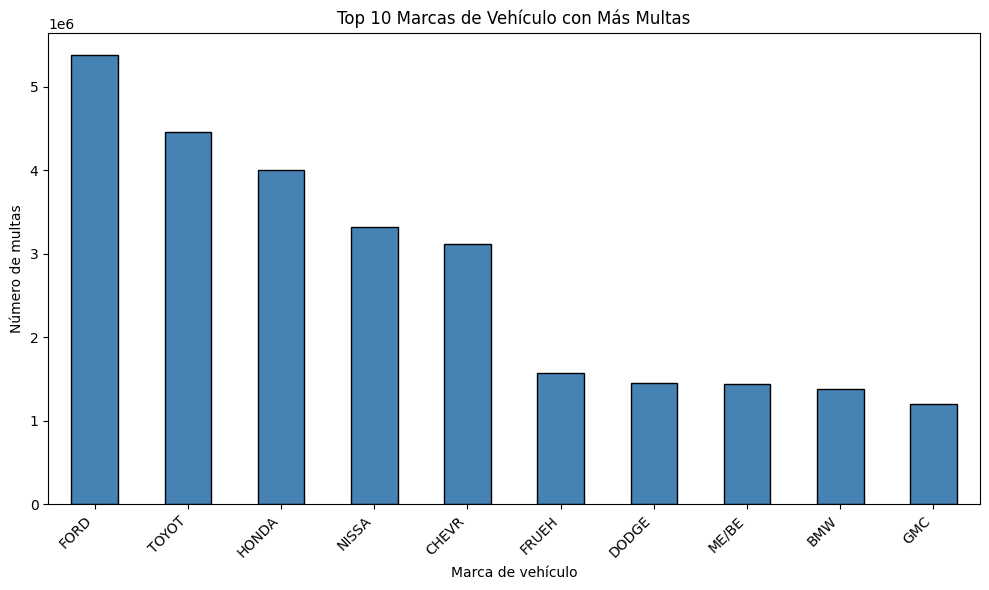

In [12]:
vc = (
    df["Vehicle Make"]
    .value_counts(split_out=16)  # evita picos de VRAM
    .compute()  # devuelve cudf.Series
    .to_pandas()  # ahora pandas.Series
)

# 4) Toma el top-10 marcas más multadas
top_makes = vc.nlargest(10)

# 5) Gráfico de barras
plt.figure(figsize=(10, 6))
top_makes.plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Top 10 Marcas de Vehículo con Más Multas")
plt.xlabel("Marca de vehículo")
plt.ylabel("Número de multas")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

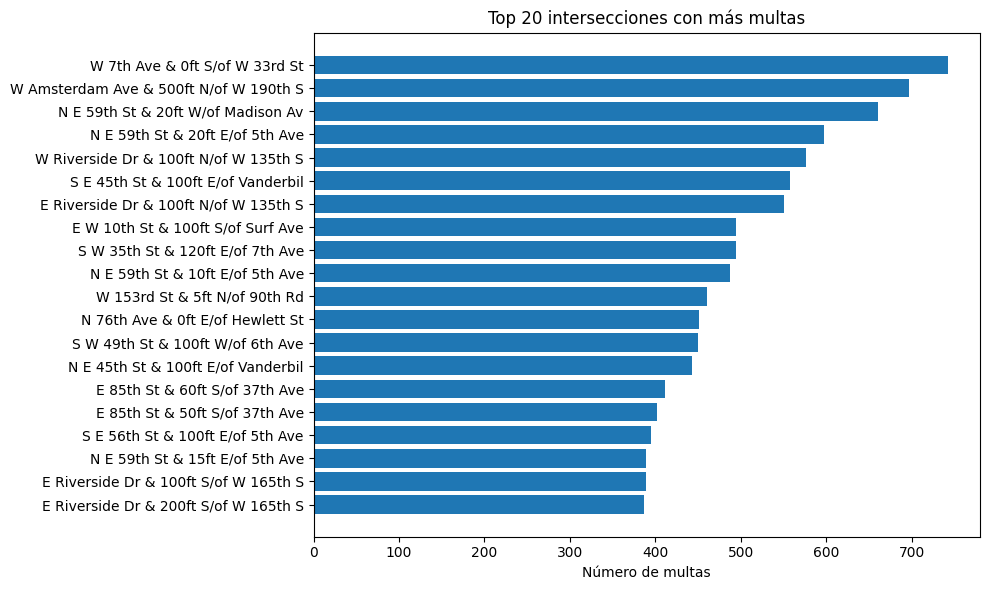

In [ ]:
# Crear columna combinada “Intersection”
df = df.assign(
    Intersection=(
        df["House Number"].astype("str")
        + " "
        + df["Street Name"]
        + " & "
        + df["Intersecting Street"]
    )
)

# Contar las 20 intersecciones con más multas
top_intersections = (
    df["Intersection"].value_counts(split_out=32).nlargest(20).compute()
)

top_intersections = top_intersections.to_pandas()


intersections = top_intersections.index.to_list()
counts = top_intersections.values.tolist()

plt.figure(figsize=(10, 6))
plt.barh(
    intersections[::-1], counts[::-1]
)  # invertido para ordenar de menor a mayor
plt.xlabel("Número de multas")
plt.title("Top 20 intersecciones con más multas")
plt.tight_layout()
plt.show()

Multas por año de vehículo (filtrado en df, 1970–2017, ≥100 multas):
Vehicle Year
1970.0        924
1971.0       1174
1972.0       1133
1973.0       1192
1974.0        929
1975.0       1077
1976.0       1113
1977.0       1568
1978.0       1773
1979.0       2258
1980.0       2435
1981.0       2253
1982.0       2775
1983.0       3973
1984.0       6352
1985.0      12573
1986.0      28050
1987.0      40096
1988.0      84614
1989.0      50447
1990.0      90596
1991.0      36017
1992.0      72183
1993.0      81271
1994.0     116066
1995.0     246082
1996.0     262945
1997.0     440082
1998.0     493320
1999.0     633633
2001.0     995748
2002.0    1158404
2003.0    1327118
2004.0    1532174
2005.0    1674529
2006.0    1813414
2007.0    2046406
2008.0    1734083
2009.0    1372862
2010.0    1555460
2011.0    1949152
2012.0    2396533
2013.0    3212610
2014.0    2793813
2015.0    2433876
2016.0    1286654
2017.0     299087
Name: count, dtype: int64


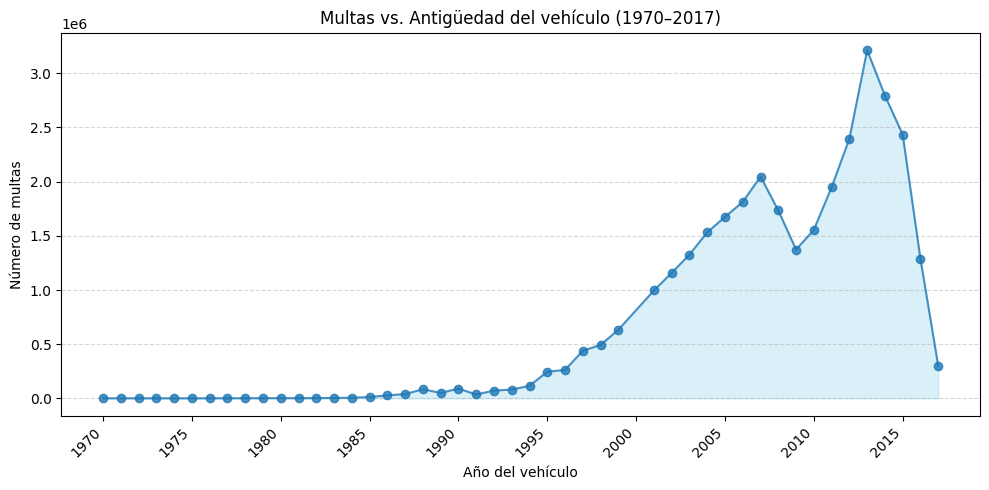

In [ ]:
min_year, max_year = 1970, 2017

# Convertimos la columna a numérico por si es string y filtramos para quedarnos solo con años razonables
# Asumiendo que la columna se llama "Vehicle Year" basándonos en el dataset original
df["Vehicle Year"] = df["Vehicle Year"].astype(float)
df_valid = df[df["Vehicle Year"].between(min_year, max_year)]

# Hacemos un conteo
year_counts_valid = (
    df_valid["Vehicle Year"].value_counts(split_out=16).compute().sort_index()
)

# Aplicamos umbral de ≥100 multas
year_counts_valid = year_counts_valid[year_counts_valid >= 100]

print("Multas por año de vehículo (filtrado en df, 1970–2017, ≥100 multas):")
print(year_counts_valid)


# Convierte a pandas para facilitar .tolist()
yc_pd = year_counts_valid.to_pandas()


# Dibuja la figura
# Extraemos los ejes
years = yc_pd.index.tolist()
counts = yc_pd.values.tolist()

# Crea figura y ejes
fig, ax = plt.subplots(figsize=(10, 5))

# Dibuja línea con markers
ax.plot(
    years,
    counts,
    marker="o",  # marcador en cada año
    linewidth=1.5,
    alpha=0.8,
    label="Multas",
)

# Rellena el área bajo la curva
ax.fill_between(years, counts, color="skyblue", alpha=0.3)

# Define ticks cada 5 años
start, end = int(years[0]), int(years[-1])
ax.set_xticks(list(range(start, end + 1, 5)))

# Etiquetas, título y grid
ax.set_xlabel("Año del vehículo")
ax.set_ylabel("Número de multas")
ax.set_title("Multas vs. Antigüedad del vehículo (1970–2017)")
ax.grid(axis="y", linestyle="--", alpha=0.5)

# Rota las etiquetas del eje X
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# Ajuste final y mostrar
plt.tight_layout()
plt.show()

In [15]:
del yc_pd
del years
del counts